In [ ]:
pip uninstall -y torch torchvision torchaudio

In [ ]:
pip install torch==2.2.2+cu118 torchvision==0.17.2+cu118 --index-url https://download.pytorch.org/whl/cu118

In [ ]:
!pip install numpy==1.26.4 --force-reinstall

In [2]:

import math
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F


# ---------------------------------------------------------------------------
# Helpers (replaces timm utilities)
# ---------------------------------------------------------------------------

def to_2tuple(x):
    return (x, x) if not isinstance(x, (list, tuple)) else tuple(x)


def trunc_normal_(tensor, mean=0., std=1., a=-2., b=2.):
    """Truncated normal initialization (in-place)."""
    with torch.no_grad():
        return _no_grad_trunc_normal_(tensor, mean, std, a, b)


def _no_grad_trunc_normal_(tensor, mean, std, a, b):
    import math
    def norm_cdf(x):
        return (1. + math.erf(x / math.sqrt(2.))) / 2.

    l = norm_cdf((a - mean) / std)
    u = norm_cdf((b - mean) / std)
    tensor.uniform_(2 * l - 1, 2 * u - 1)
    tensor.erfinv_()
    tensor.mul_(std * math.sqrt(2.))
    tensor.add_(mean)
    tensor.clamp_(min=a, max=b)
    return tensor


class DropPath(nn.Module):
    """Stochastic depth (drop paths) per sample."""

    def __init__(self, drop_prob=0.):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        if self.drop_prob == 0. or not self.training:
            return x
        keep_prob = 1 - self.drop_prob
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        random_tensor = torch.rand(shape, dtype=x.dtype, device=x.device)
        random_tensor = torch.floor(random_tensor + keep_prob)
        return x * random_tensor / keep_prob


# ---------------------------------------------------------------------------
# Backbone components
# ---------------------------------------------------------------------------

class DWConv(nn.Module):
    """Depth-wise convolution used inside the MLP block."""

    def __init__(self, dim=768):
        super().__init__()
        self.dwconv = nn.Conv2d(dim, dim, 3, 1, 1, bias=True, groups=dim)

    def forward(self, x, H, W):
        B, N, C = x.shape
        x = x.transpose(1, 2).view(B, C, H, W)
        x = self.dwconv(x)
        x = x.flatten(2).transpose(1, 2)
        return x


class Mlp(nn.Module):
    def __init__(self, in_features, hidden_features=None, out_features=None,
                 act_layer=nn.GELU, drop=0.):
        super().__init__()
        out_features = out_features or in_features
        hidden_features = hidden_features or in_features
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.dwconv = DWConv(hidden_features)
        self.act = act_layer()
        self.fc2 = nn.Linear(hidden_features, out_features)
        self.drop = nn.Dropout(drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = self.fc1(x)
        x = self.dwconv(x, H, W)
        x = self.act(x)
        x = self.drop(x)
        x = self.fc2(x)
        x = self.drop(x)
        return x


class Attention(nn.Module):
    def __init__(self, dim, num_heads=8, qkv_bias=False, qk_scale=None,
                 attn_drop=0., proj_drop=0., sr_ratio=1):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        head_dim = dim // num_heads
        self.scale = qk_scale or head_dim ** -0.5

        self.q = nn.Linear(dim, dim, bias=qkv_bias)
        self.kv = nn.Linear(dim, dim * 2, bias=qkv_bias)
        self.attn_drop = nn.Dropout(attn_drop)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(proj_drop)

        self.sr_ratio = sr_ratio
        if sr_ratio > 1:
            self.sr = nn.Conv2d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio)
            self.norm = nn.LayerNorm(dim)

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        B, N, C = x.shape
        q = self.q(x).reshape(B, N, self.num_heads, C // self.num_heads).permute(0, 2, 1, 3)

        if self.sr_ratio > 1:
            x_ = x.permute(0, 2, 1).reshape(B, C, H, W)
            x_ = self.sr(x_).reshape(B, C, -1).permute(0, 2, 1)
            x_ = self.norm(x_)
            kv = self.kv(x_).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)
        else:
            kv = self.kv(x).reshape(B, -1, 2, self.num_heads, C // self.num_heads).permute(2, 0, 3, 1, 4)

        k, v = kv[0], kv[1]
        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.attn_drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        x = self.proj_drop(x)
        return x


class Block(nn.Module):
    def __init__(self, dim, num_heads, mlp_ratio=4., qkv_bias=False, qk_scale=None,
                 drop=0., attn_drop=0., drop_path=0., act_layer=nn.GELU,
                 norm_layer=nn.LayerNorm, sr_ratio=1):
        super().__init__()
        self.norm1 = norm_layer(dim)
        self.attn = Attention(dim, num_heads=num_heads, qkv_bias=qkv_bias,
                              qk_scale=qk_scale, attn_drop=attn_drop,
                              proj_drop=drop, sr_ratio=sr_ratio)
        self.drop_path = DropPath(drop_path) if drop_path > 0. else nn.Identity()
        self.norm2 = norm_layer(dim)
        self.mlp = Mlp(in_features=dim, hidden_features=int(dim * mlp_ratio),
                       act_layer=act_layer, drop=drop)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x, H, W):
        x = x + self.drop_path(self.attn(self.norm1(x), H, W))
        x = x + self.drop_path(self.mlp(self.norm2(x), H, W))
        return x


class OverlapPatchEmbed(nn.Module):
    """Image to Patch Embedding with overlapping patches."""

    def __init__(self, img_size=224, patch_size=7, stride=4, in_chans=3, embed_dim=768):
        super().__init__()
        img_size = to_2tuple(img_size)
        patch_size = to_2tuple(patch_size)
        self.img_size = img_size
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_chans, embed_dim, kernel_size=patch_size, stride=stride,
                              padding=(patch_size[0] // 2, patch_size[1] // 2))
        self.norm = nn.LayerNorm(embed_dim)
        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        x = self.proj(x)
        _, _, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        x = self.norm(x)
        return x, H, W


class MixVisionTransformer(nn.Module):
    """Mix-Transformer backbone (encoder) for SegFormer."""

    def __init__(self, img_size=224, in_chans=3,
                 embed_dims=[64, 128, 256, 512],
                 num_heads=[1, 2, 4, 8],
                 mlp_ratios=[4, 4, 4, 4],
                 qkv_bias=False, qk_scale=None,
                 drop_rate=0., attn_drop_rate=0., drop_path_rate=0.,
                 norm_layer=nn.LayerNorm,
                 depths=[3, 4, 6, 3],
                 sr_ratios=[8, 4, 2, 1]):
        super().__init__()
        self.depths = depths

        # Patch embeddings
        self.patch_embed1 = OverlapPatchEmbed(img_size=img_size, patch_size=7, stride=4,
                                              in_chans=in_chans, embed_dim=embed_dims[0])
        self.patch_embed2 = OverlapPatchEmbed(img_size=img_size // 4, patch_size=3, stride=2,
                                              in_chans=embed_dims[0], embed_dim=embed_dims[1])
        self.patch_embed3 = OverlapPatchEmbed(img_size=img_size // 8, patch_size=3, stride=2,
                                              in_chans=embed_dims[1], embed_dim=embed_dims[2])
        self.patch_embed4 = OverlapPatchEmbed(img_size=img_size // 16, patch_size=3, stride=2,
                                              in_chans=embed_dims[2], embed_dim=embed_dims[3])

        # Stochastic depth decay
        dpr = [x.item() for x in torch.linspace(0, drop_path_rate, sum(depths))]
        cur = 0

        self.block1 = nn.ModuleList([
            Block(dim=embed_dims[0], num_heads=num_heads[0], mlp_ratio=mlp_ratios[0],
                  qkv_bias=qkv_bias, qk_scale=qk_scale, drop=drop_rate,
                  attn_drop=attn_drop_rate, drop_path=dpr[cur + i],
                  norm_layer=norm_layer, sr_ratio=sr_ratios[0])
            for i in range(depths[0])])
        self.norm1 = norm_layer(embed_dims[0])
        cur += depths[0]

        self.block2 = nn.ModuleList([
            Block(dim=embed_dims[1], num_heads=num_heads[1], mlp_ratio=mlp_ratios[1],
                  qkv_bias=qkv_bias, qk_scale=qk_scale, drop=drop_rate,
                  attn_drop=attn_drop_rate, drop_path=dpr[cur + i],
                  norm_layer=norm_layer, sr_ratio=sr_ratios[1])
            for i in range(depths[1])])
        self.norm2 = norm_layer(embed_dims[1])
        cur += depths[1]

        self.block3 = nn.ModuleList([
            Block(dim=embed_dims[2], num_heads=num_heads[2], mlp_ratio=mlp_ratios[2],
                  qkv_bias=qkv_bias, qk_scale=qk_scale, drop=drop_rate,
                  attn_drop=attn_drop_rate, drop_path=dpr[cur + i],
                  norm_layer=norm_layer, sr_ratio=sr_ratios[2])
            for i in range(depths[2])])
        self.norm3 = norm_layer(embed_dims[2])
        cur += depths[2]

        self.block4 = nn.ModuleList([
            Block(dim=embed_dims[3], num_heads=num_heads[3], mlp_ratio=mlp_ratios[3],
                  qkv_bias=qkv_bias, qk_scale=qk_scale, drop=drop_rate,
                  attn_drop=attn_drop_rate, drop_path=dpr[cur + i],
                  norm_layer=norm_layer, sr_ratio=sr_ratios[3])
            for i in range(depths[3])])
        self.norm4 = norm_layer(embed_dims[3])

        self.apply(self._init_weights)

    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            trunc_normal_(m.weight, std=.02)
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
        elif isinstance(m, nn.LayerNorm):
            nn.init.constant_(m.bias, 0)
            nn.init.constant_(m.weight, 1.0)
        elif isinstance(m, nn.Conv2d):
            fan_out = m.kernel_size[0] * m.kernel_size[1] * m.out_channels // m.groups
            m.weight.data.normal_(0, math.sqrt(2.0 / fan_out))
            if m.bias is not None:
                m.bias.data.zero_()

    def forward(self, x):
        B = x.shape[0]
        outs = []

        # Stage 1
        x, H, W = self.patch_embed1(x)
        for blk in self.block1:
            x = blk(x, H, W)
        x = self.norm1(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        outs.append(x)

        # Stage 2
        x, H, W = self.patch_embed2(x)
        for blk in self.block2:
            x = blk(x, H, W)
        x = self.norm2(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        outs.append(x)

        # Stage 3
        x, H, W = self.patch_embed3(x)
        for blk in self.block3:
            x = blk(x, H, W)
        x = self.norm3(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        outs.append(x)

        # Stage 4
        x, H, W = self.patch_embed4(x)
        for blk in self.block4:
            x = blk(x, H, W)
        x = self.norm4(x)
        x = x.reshape(B, H, W, -1).permute(0, 3, 1, 2).contiguous()
        outs.append(x)

        return outs  # [C1, C2, C3, C4] at strides [4, 8, 16, 32]


# ---------------------------------------------------------------------------
# Decoder head
# ---------------------------------------------------------------------------

class LinearMLP(nn.Module):
    """Linear projection to a common embedding dimension."""

    def __init__(self, input_dim=2048, embed_dim=768):
        super().__init__()
        self.proj = nn.Linear(input_dim, embed_dim)

    def forward(self, x):
        # x: (B, C, H, W)  ->  (B, H*W, embed_dim)
        x = x.flatten(2).transpose(1, 2)
        x = self.proj(x)
        return x


class SegFormerHead(nn.Module):
    """
    All-MLP decoder from SegFormer.
    Fuses multi-scale features C1–C4 into a single segmentation map.
    """

    def __init__(self, in_channels, num_classes, embedding_dim=256, dropout=0.1):
        """
        Args:
            in_channels (list[int]): channel dims of [C1, C2, C3, C4].
            num_classes (int): number of segmentation classes.
            embedding_dim (int): unified projection dimension.
            dropout (float): dropout before final prediction.
        """
        super().__init__()
        c1_in, c2_in, c3_in, c4_in = in_channels

        self.linear_c4 = LinearMLP(input_dim=c4_in, embed_dim=embedding_dim)
        self.linear_c3 = LinearMLP(input_dim=c3_in, embed_dim=embedding_dim)
        self.linear_c2 = LinearMLP(input_dim=c2_in, embed_dim=embedding_dim)
        self.linear_c1 = LinearMLP(input_dim=c1_in, embed_dim=embedding_dim)

        # 1x1 conv + BN to fuse concatenated features
        self.linear_fuse = nn.Sequential(
            nn.Conv2d(embedding_dim * 4, embedding_dim, kernel_size=1, bias=False),
            nn.BatchNorm2d(embedding_dim),
            nn.ReLU(inplace=True),
        )

        self.dropout = nn.Dropout2d(dropout)
        self.linear_pred = nn.Conv2d(embedding_dim, num_classes, kernel_size=1)

    def forward(self, features):
        """
        Args:
            features (list[Tensor]): [C1, C2, C3, C4]
                C1: (B, c1_in, H/4,  W/4)
                C2: (B, c2_in, H/8,  W/8)
                C3: (B, c3_in, H/16, W/16)
                C4: (B, c4_in, H/32, W/32)

        Returns:
            Tensor: (B, num_classes, H/4, W/4)  — upsampled to C1 resolution.
        """
        c1, c2, c3, c4 = features
        n, _, h, w = c4.shape
        target_size = c1.shape[2:]  # (H/4, W/4)

        _c4 = self.linear_c4(c4).permute(0, 2, 1).reshape(n, -1, c4.shape[2], c4.shape[3])
        _c4 = F.interpolate(_c4, size=target_size, mode='bilinear', align_corners=False)

        _c3 = self.linear_c3(c3).permute(0, 2, 1).reshape(n, -1, c3.shape[2], c3.shape[3])
        _c3 = F.interpolate(_c3, size=target_size, mode='bilinear', align_corners=False)

        _c2 = self.linear_c2(c2).permute(0, 2, 1).reshape(n, -1, c2.shape[2], c2.shape[3])
        _c2 = F.interpolate(_c2, size=target_size, mode='bilinear', align_corners=False)

        _c1 = self.linear_c1(c1).permute(0, 2, 1).reshape(n, -1, c1.shape[2], c1.shape[3])

        _c = self.linear_fuse(torch.cat([_c4, _c3, _c2, _c1], dim=1))
        x = self.dropout(_c)
        x = self.linear_pred(x)
        return x


# ---------------------------------------------------------------------------
# Full SegFormer model
# ---------------------------------------------------------------------------

class SegFormer(nn.Module):
    """
    End-to-end SegFormer model.

    Args:
        img_size (int): input image size (assumed square). Default: 512.
        in_chans (int): number of input channels. Default: 3.
        num_classes (int): number of segmentation classes.
        embed_dims (list[int]): embedding dimensions per stage.
        num_heads (list[int]): number of attention heads per stage.
        mlp_ratios (list[int]): MLP expansion ratio per stage.
        qkv_bias (bool): use bias in QKV projection. Default: True.
        depths (list[int]): number of transformer blocks per stage.
        sr_ratios (list[int]): spatial-reduction ratios per stage.
        drop_rate (float): dropout rate.
        drop_path_rate (float): stochastic depth rate.
        decoder_embedding_dim (int): projection dimension in the decoder.
        decoder_dropout (float): dropout in the decoder head.

    Usage:
        model = SegFormer(num_classes=19)            # mit-b2 config by default
        model = SegFormer.from_variant('b0', num_classes=19)
        logits = model(x)                            # (B, num_classes, H/4, W/4)
        # upsample to original resolution:
        out = F.interpolate(logits, size=x.shape[2:], mode='bilinear', align_corners=False)
    """

    # Pre-defined variant configs  (depths + embed_dims; rest is shared)
    _VARIANTS = {
        'b0': dict(embed_dims=[32, 64, 160, 256],  depths=[2, 2, 2, 2]),
        'b1': dict(embed_dims=[64, 128, 320, 512], depths=[2, 2, 2, 2]),
        'b2': dict(embed_dims=[64, 128, 320, 512], depths=[3, 4, 6, 3]),
        'b3': dict(embed_dims=[64, 128, 320, 512], depths=[3, 4, 18, 3]),
        'b4': dict(embed_dims=[64, 128, 320, 512], depths=[3, 8, 27, 3]),
        'b5': dict(embed_dims=[64, 128, 320, 512], depths=[3, 6, 40, 3]),
    }

    def __init__(self,
                 img_size=256,
                 in_chans=3,
                 num_classes=2,
                 embed_dims=[64, 128, 320, 512],
                 num_heads=[1, 2, 5, 8],
                 mlp_ratios=[4, 4, 4, 4],
                 qkv_bias=True,
                 depths=[3, 4, 6, 3],
                 sr_ratios=[8, 4, 2, 1],
                 drop_rate=0.0,
                 drop_path_rate=0.1,
                 decoder_embedding_dim=256,
                 decoder_dropout=0.1):
        super().__init__()

        self.backbone = MixVisionTransformer(
            img_size=img_size,
            in_chans=in_chans,
            embed_dims=embed_dims,
            num_heads=num_heads,
            mlp_ratios=mlp_ratios,
            qkv_bias=qkv_bias,
            qk_scale=None,
            drop_rate=drop_rate,
            attn_drop_rate=0.,
            drop_path_rate=drop_path_rate,
            norm_layer=partial(nn.LayerNorm, eps=1e-6),
            depths=depths,
            sr_ratios=sr_ratios,
        )

        self.decode_head = SegFormerHead(
            in_channels=embed_dims,
            num_classes=num_classes,
            embedding_dim=decoder_embedding_dim,
            dropout=decoder_dropout,
        )

    @classmethod
    def from_variant(cls, variant: str, **kwargs):
        """
        Convenience constructor.

        Example:
            model = SegFormer.from_variant('b2', num_classes=19)
        """
        assert variant in cls._VARIANTS, f"Unknown variant '{variant}'. Choose from {list(cls._VARIANTS.keys())}"
        cfg = cls._VARIANTS[variant]
        return cls(embed_dims=cfg['embed_dims'], depths=cfg['depths'], **kwargs)

    def forward(self, x):
        """
        Args:
            x (Tensor): (B, 3, H, W)

        Returns:
            Tensor: (B, num_classes, H/4, W/4)
            Use F.interpolate(..., size=(H, W)) to get full-resolution output.
        """
        features = self.backbone(x)
        out = self.decode_head(features)
        return out


# ---------------------------------------------------------------------------
# Quick sanity-check
# ---------------------------------------------------------------------------

if __name__ == '__main__':
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    for variant in ['b0', 'b1', 'b2']:
        model = SegFormer.from_variant(variant, num_classes=19, img_size=512).to(device)
        model.eval()
        dummy = torch.randn(2, 3, 512, 512).to(device)
        with torch.no_grad():
            out = model(dummy)
        print(f"SegFormer-{variant}: input {tuple(dummy.shape)} -> logits {tuple(out.shape)}")
        # upsample back to full res
        full = F.interpolate(out, size=(512, 512), mode='bilinear', align_corners=False)
        print(f"   after upsample: {tuple(full.shape)}")

SegFormer-b0: input (2, 3, 512, 512) -> logits (2, 19, 128, 128)
   after upsample: (2, 19, 512, 512)
SegFormer-b1: input (2, 3, 512, 512) -> logits (2, 19, 128, 128)
   after upsample: (2, 19, 512, 512)
SegFormer-b2: input (2, 3, 512, 512) -> logits (2, 19, 128, 128)
   after upsample: (2, 19, 512, 512)


In [3]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from PIL import Image
from glob import glob

# ---------- seed ----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ---------- transforms ----------
IMAGE_SIZE = 256
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform_img = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_mask_binary = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=Image.NEAREST),
    transforms.PILToTensor()
])

def to_long_binary(mask_tensor):
    """Chuyển mask tensor về (H, W) với giá trị 0/1 long"""
    if mask_tensor.ndim == 3:
        mask_tensor = mask_tensor.squeeze(0)
    mask_bin = (mask_tensor > 0).long()
    return mask_bin

# ---------- Dataset A: image + binary mask ----------
class SegmentationDatasetA(Dataset):
    def __init__(self, image_dir, mask_dir, transform_img=None, transform_mask=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.JPG")))
        self.mask_paths = []
        for img_path in self.image_paths:
            basename = os.path.splitext(os.path.basename(img_path))[0]
            mask_path = os.path.join(mask_dir, basename + ".PNG")
            if not os.path.exists(mask_path):
                raise FileNotFoundError(f"Mask not found: {mask_path}")
            self.mask_paths.append(mask_path)
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        if self.transform_img:
            img = self.transform_img(img)
        if self.transform_mask:
            mask = self.transform_mask(mask)
        mask = to_long_binary(mask)
        return img, mask, "hard"

# ---------- Dataset B: image + soft label ----------
class SoftLabelDatasetB(Dataset):
    def __init__(self, image_dir, soft_label_dir, temperature=1.0, transform_img=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
        self.soft_paths = []
        for img_path in self.image_paths:
            basename = os.path.splitext(os.path.basename(img_path))[0]
            soft_path = os.path.join(soft_label_dir, basename + ".npy")
            if not os.path.exists(soft_path):
                raise FileNotFoundError(f"Soft label not found: {soft_path}")
            self.soft_paths.append(soft_path)
        self.temperature = temperature
        self.transform_img = transform_img

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        soft_logits = np.load(self.soft_paths[idx])
        if soft_logits.ndim == 3 and soft_logits.shape[-1] in [2, 3, 4]:
            soft_logits = torch.from_numpy(soft_logits).permute(2, 0, 1)
        else:
            soft_logits = torch.from_numpy(soft_logits)
        if soft_logits.shape[1:] != (IMAGE_SIZE, IMAGE_SIZE):
            soft_logits = F.interpolate(soft_logits.unsqueeze(0), size=(IMAGE_SIZE, IMAGE_SIZE),
                                        mode='bilinear', align_corners=False).squeeze(0)
        soft_probs = torch.softmax(soft_logits / self.temperature, dim=0)
        if self.transform_img:
            img = self.transform_img(img)
        return img, soft_probs, "soft"

# ---------- custom collate_fn ----------
def collate_mixed(batch):
    imgs = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]
    types = [item[2] for item in batch]
    return imgs, targets, types

# ---------- Balanced Train Loader (gộp hard và soft theo tỷ lệ cố định) ----------
class BalancedTrainLoader:
    """
    Dataloader kết hợp hai dataset (hard và soft), mỗi batch lấy số lượng cố định từ mỗi loại.
    """
    def __init__(self, dataset_hard, dataset_soft, batch_size_hard=4, batch_size_soft=4,
                 shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_mixed):
        self.loader_hard = DataLoader(dataset_hard, batch_size=batch_size_hard, shuffle=shuffle,
                                      num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_fn)
        self.loader_soft = DataLoader(dataset_soft, batch_size=batch_size_soft, shuffle=shuffle,
                                      num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_fn)
        self.batch_size_hard = batch_size_hard
        self.batch_size_soft = batch_size_soft

    def __iter__(self):
        self.iter_hard = iter(self.loader_hard)
        self.iter_soft = iter(self.loader_soft)
        return self

    def __next__(self):
        try:
            batch_hard = next(self.iter_hard)
            batch_soft = next(self.iter_soft)
        except StopIteration:
            raise StopIteration
        imgs_hard, targets_hard, types_hard = batch_hard
        imgs_soft, targets_soft, types_soft = batch_soft
        # Ghép theo batch dimension
        imgs = torch.cat([imgs_hard, imgs_soft], dim=0)
        targets = targets_hard + targets_soft
        types = list(types_hard) + list(types_soft)
        return imgs, targets, types

    def __len__(self):
        return min(len(self.loader_hard), len(self.loader_soft))

# ---------- Hàm tạo DataLoader cho train/val/test ----------
def get_dataloaders(datasetA_root, datasetB_root, temperature=1.0, batch_size=8, num_workers=4, pin_memory=True):
    # Dataset A (hard)
    train_img_dir = os.path.join(datasetA_root, "train/images")
    train_mask_dir = os.path.join(datasetA_root, "train/masks")
    val_img_dir   = os.path.join(datasetA_root, "validation/images")
    val_mask_dir   = os.path.join(datasetA_root, "validation/masks")
    test_img_dir   = os.path.join(datasetA_root, "test/images")
    test_mask_dir  = os.path.join(datasetA_root, "test/masks")

    datasetA_train = SegmentationDatasetA(train_img_dir, train_mask_dir, transform_img, transform_mask_binary)
    datasetA_val   = SegmentationDatasetA(val_img_dir, val_mask_dir, transform_img, transform_mask_binary)
    datasetA_test  = SegmentationDatasetA(test_img_dir, test_mask_dir, transform_img, transform_mask_binary)

    # Dataset B (soft)
    datasetB_img_dir = os.path.join(datasetB_root, "images")
    datasetB_soft_dir = os.path.join(datasetB_root, "soft_labels_npy")
    datasetB_train = SoftLabelDatasetB(datasetB_img_dir, datasetB_soft_dir, temperature, transform_img)

    # DataLoaders riêng
    train_loader_hard = DataLoader(datasetA_train, batch_size=batch_size, shuffle=True,
                                   num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)
    train_loader_soft = DataLoader(datasetB_train, batch_size=batch_size, shuffle=True,
                                   num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)
    val_loader = DataLoader(datasetA_val, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)
    test_loader = DataLoader(datasetA_test, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)

    print(f"Train hard size: {len(datasetA_train)}, Train soft size: {len(datasetB_train)}")
    print(f"Val size: {len(datasetA_val)}, Test size: {len(datasetA_test)}")
    return train_loader_hard, train_loader_soft, val_loader, test_loader

# ---------- ví dụ sử dụng ----------
if __name__ == "__main__":
    datasetA_root = "/kaggle/input/datasets/totrang24082004/otu2d-dataset/dataset_split"
    datasetB_root = "/kaggle/input/datasets/totrang24082004/sample"

    # Tạo dataset A (hard)
    train_img_dir = os.path.join(datasetA_root, "train/images")
    train_mask_dir = os.path.join(datasetA_root, "train/masks")
    datasetA_train = SegmentationDatasetA(train_img_dir, train_mask_dir, transform_img, transform_mask_binary)

    # Tạo dataset B (soft)
    datasetB_img_dir = os.path.join(datasetB_root, "images")
    datasetB_soft_dir = os.path.join(datasetB_root, "soft_labels_npy")
    datasetB_train = SoftLabelDatasetB(datasetB_img_dir, datasetB_soft_dir, temperature=12.0, transform_img=transform_img)

    # Tạo balanced loader
    balanced_loader = BalancedTrainLoader(datasetA_train, datasetB_train,
                                          batch_size_hard=8, batch_size_soft=8,
                                          shuffle=True, num_workers=2, pin_memory=True, collate_fn=collate_mixed)

    # Kiểm tra batch
    for imgs, targets, types in balanced_loader:
        print("Batch images shape:", imgs.shape)
        print("Number of targets:", len(targets))
        hard_count = types.count('hard')
        soft_count = types.count('soft')
        print(f"Hard count: {hard_count}, Soft count: {soft_count}")
        print("Types:", types[:5])
        break

Batch images shape: torch.Size([16, 3, 256, 256])
Number of targets: 16
Hard count: 8, Soft count: 8
Types: ['hard', 'hard', 'hard', 'hard', 'hard']


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset
from torchvision import transforms
from PIL import Image
from glob import glob

# ---------- seed ----------
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# ---------- transforms ----------
IMAGE_SIZE = 256
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform_img = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_mask_binary = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=Image.NEAREST),
    transforms.PILToTensor()
])

def to_long_binary(mask_tensor):
    """Chuyển mask tensor về (H, W) với giá trị 0/1 long"""
    if mask_tensor.ndim == 3:
        mask_tensor = mask_tensor.squeeze(0)
    mask_bin = (mask_tensor > 0).long()
    return mask_bin

# ---------- Dataset A: image + binary mask ----------
class SegmentationDatasetA(Dataset):
    def __init__(self, image_dir, mask_dir, transform_img=None, transform_mask=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.JPG")))
        self.mask_paths = []
        for img_path in self.image_paths:
            basename = os.path.splitext(os.path.basename(img_path))[0]
            mask_path = os.path.join(mask_dir, basename + ".PNG")
            if not os.path.exists(mask_path):
                raise FileNotFoundError(f"Mask not found: {mask_path}")
            self.mask_paths.append(mask_path)
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        if self.transform_img:
            img = self.transform_img(img)
        if self.transform_mask:
            mask = self.transform_mask(mask)
        mask = to_long_binary(mask)
        return img, mask, "hard"

# ---------- Dataset B: image + soft label ----------
class SoftLabelDatasetB(Dataset):
    def __init__(self, image_dir, soft_label_dir, temperature=1.0, transform_img=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.jpg")))
        self.soft_paths = []

        for img_path in self.image_paths:
            # Ví dụ: img_0000.jpg -> 0000
            basename = os.path.splitext(os.path.basename(img_path))[0]
            idx = basename.replace("img_", "")

            # Tạo đường dẫn soft label tương ứng
            soft_path = os.path.join(
                soft_label_dir,
                f"soft_label_{idx}.npy"
            )

            if not os.path.exists(soft_path):
                raise FileNotFoundError(
                    f"Soft label not found: {soft_path}"
                )

            self.soft_paths.append(soft_path)

        self.temperature = temperature
        self.transform_img = transform_img

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")

        soft_logits = np.load(self.soft_paths[idx])

        soft_logits = torch.from_numpy(soft_logits).float()

        # Nếu logits có dạng (H,W,C) -> (C,H,W)
        if soft_logits.ndim == 3 and soft_logits.shape[-1] in [2, 3, 4]:
            soft_logits = soft_logits.permute(2, 0, 1)

        # Resize nếu cần
        if soft_logits.shape[1:] != (IMAGE_SIZE, IMAGE_SIZE):
            soft_logits = F.interpolate(
                soft_logits.unsqueeze(0),
                size=(IMAGE_SIZE, IMAGE_SIZE),
                mode="bilinear",
                align_corners=False
            ).squeeze(0)

        soft_probs = torch.softmax(
            soft_logits / self.temperature,
            dim=0
        )

        if self.transform_img:
            img = self.transform_img(img)

        return img, soft_probs, "soft"

# ---------- custom collate_fn ----------
def collate_mixed(batch):
    imgs = torch.stack([item[0] for item in batch])
    targets = [item[1] for item in batch]
    types = [item[2] for item in batch]
    return imgs, targets, types

# ---------- Balanced Train Loader (gộp hard và soft theo tỷ lệ cố định) ----------
class BalancedTrainLoader:
    """
    Dataloader kết hợp hai dataset (hard và soft), mỗi batch lấy số lượng cố định từ mỗi loại.
    """
    def __init__(self, dataset_hard, dataset_soft, batch_size_hard=4, batch_size_soft=4,
                 shuffle=True, num_workers=0, pin_memory=True, collate_fn=collate_mixed):
        self.loader_hard = DataLoader(dataset_hard, batch_size=batch_size_hard, shuffle=shuffle,
                                      num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_fn)
        self.loader_soft = DataLoader(dataset_soft, batch_size=batch_size_soft, shuffle=shuffle,
                                      num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_fn)
        self.batch_size_hard = batch_size_hard
        self.batch_size_soft = batch_size_soft

    def __iter__(self):
        self.iter_hard = iter(self.loader_hard)
        self.iter_soft = iter(self.loader_soft)
        return self

    def __next__(self):
        try:
            batch_hard = next(self.iter_hard)
            batch_soft = next(self.iter_soft)
        except StopIteration:
            raise StopIteration
        imgs_hard, targets_hard, types_hard = batch_hard
        imgs_soft, targets_soft, types_soft = batch_soft
        # Ghép theo batch dimension
        imgs = torch.cat([imgs_hard, imgs_soft], dim=0)
        targets = targets_hard + targets_soft
        types = list(types_hard) + list(types_soft)
        return imgs, targets, types

    def __len__(self):
        return min(len(self.loader_hard), len(self.loader_soft))

# ---------- Hàm tạo DataLoader cho train/val/test ----------
def get_dataloaders(datasetA_root, datasetB_root, temperature=1.0, batch_size=8, num_workers=4, pin_memory=True):
    # Dataset A (hard)
    train_img_dir = os.path.join(datasetA_root, "train/images")
    train_mask_dir = os.path.join(datasetA_root, "train/masks")
    val_img_dir   = os.path.join(datasetA_root, "validation/images")
    val_mask_dir   = os.path.join(datasetA_root, "validation/masks")
    test_img_dir   = os.path.join(datasetA_root, "test/images")
    test_mask_dir  = os.path.join(datasetA_root, "test/masks")

    datasetA_train = SegmentationDatasetA(train_img_dir, train_mask_dir, transform_img, transform_mask_binary)
    datasetA_val   = SegmentationDatasetA(val_img_dir, val_mask_dir, transform_img, transform_mask_binary)
    datasetA_test  = SegmentationDatasetA(test_img_dir, test_mask_dir, transform_img, transform_mask_binary)

    # Dataset B (soft)
    datasetB_img_dir = os.path.join(datasetB_root, "images")
    datasetB_soft_dir = os.path.join(datasetB_root, "soft_labels_npy")
    datasetB_train = SoftLabelDatasetB(datasetB_img_dir, datasetB_soft_dir, temperature, transform_img)

    # DataLoaders riêng
    train_loader_hard = DataLoader(datasetA_train, batch_size=batch_size, shuffle=True,
                                   num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)
    train_loader_soft = DataLoader(datasetB_train, batch_size=batch_size, shuffle=True,
                                   num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)
    val_loader = DataLoader(datasetA_val, batch_size=batch_size, shuffle=False,
                            num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)
    test_loader = DataLoader(datasetA_test, batch_size=batch_size, shuffle=False,
                             num_workers=num_workers, pin_memory=pin_memory, collate_fn=collate_mixed)

    print(f"Train hard size: {len(datasetA_train)}, Train soft size: {len(datasetB_train)}")
    print(f"Val size: {len(datasetA_val)}, Test size: {len(datasetA_test)}")
    return train_loader_hard, train_loader_soft, val_loader, test_loader

# ---------- ví dụ sử dụng ----------
if __name__ == "__main__":
    datasetA_root = "/kaggle/input/datasets/totrang24082004/otu2d-dataset/dataset_split"
    datasetB_root = "/kaggle/input/datasets/totrang24082004/sample"

    # Tạo dataset A (hard)
    train_img_dir = os.path.join(datasetA_root, "train/images")
    train_mask_dir = os.path.join(datasetA_root, "train/masks")
    datasetA_train = SegmentationDatasetA(train_img_dir, train_mask_dir, transform_img, transform_mask_binary)

    # Tạo dataset B (soft)
    datasetB_img_dir = os.path.join(datasetB_root, "images")
    datasetB_soft_dir = os.path.join(datasetB_root, "soft_labels_npy")
    datasetB_train = SoftLabelDatasetB(datasetB_img_dir, datasetB_soft_dir, temperature=12.0, transform_img=transform_img)

    # Tạo balanced loader
    balanced_loader = BalancedTrainLoader(datasetA_train, datasetB_train,
                                          batch_size_hard=8, batch_size_soft=8,
                                          shuffle=True, num_workers=2, pin_memory=True, collate_fn=collate_mixed)

    # Kiểm tra batch
    for imgs, targets, types in balanced_loader:
        print("Batch images shape:", imgs.shape)
        print("Number of targets:", len(targets))
        hard_count = types.count('hard')
        soft_count = types.count('soft')
        print(f"Hard count: {hard_count}, Soft count: {soft_count}")
        print("Types:", types[:5])
        break

In [4]:
 
import os
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm import tqdm
 
# -----------------------------------------------------------------------
# 1.  LOSS FUNCTIONS
# -----------------------------------------------------------------------
 
class DiceLoss(nn.Module):
    """
    Binary Dice loss — works on logits (applies sigmoid internally).
    Expects:
        pred  : (B, 1, H, W)  or  (B, H, W)   raw logits
        target: (B, H, W)                      long 0/1
    """
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
 
    def forward(self, pred, target):
        if pred.dim() == 4 and pred.shape[1] == 1:
            pred = pred.squeeze(1)                    # (B, H, W)
        pred_prob = torch.sigmoid(pred)               # (B, H, W)
        target_f  = target.float()                    # (B, H, W)
 
        intersection = (pred_prob * target_f).sum(dim=(1, 2))
        union        = pred_prob.sum(dim=(1, 2)) + target_f.sum(dim=(1, 2))
        dice         = (2. * intersection + self.smooth) / (union + self.smooth)
        return 1. - dice.mean()
 
 
class HardLoss(nn.Module):
    """
    L_stu (Dataset A) = λ_ce * BCE + λ_dice * Dice
    Expects:
        logits : (B, 1, H, W)   or  (B, H, W)
        targets: list of (H, W) long tensors
    """
    def __init__(self, lambda_ce=1.0, lambda_dice=1.0):
        super().__init__()
        self.lambda_ce   = lambda_ce
        self.lambda_dice = lambda_dice
        self.dice_fn     = DiceLoss()
 
    def forward(self, logits, targets):
        # logits: (B, 1, H, W) from SegFormer head — squeeze to (B, H, W)
        if logits.dim() == 4 and logits.shape[1] == 1:
            logits = logits.squeeze(1)
 
        # stack targets → (B, H, W) long
        target_tensor = torch.stack(targets, dim=0).to(logits.device)  # (B, H, W)
 
        # resize target to logit spatial size if needed
        if target_tensor.shape[-2:] != logits.shape[-2:]:
            target_tensor = F.interpolate(
                target_tensor.unsqueeze(1).float(),
                size=logits.shape[-2:], mode='nearest'
            ).squeeze(1).long()
 
        l_ce   = F.binary_cross_entropy_with_logits(logits, target_tensor.float())
        l_dice = self.dice_fn(logits, target_tensor)
        return self.lambda_ce * l_ce + self.lambda_dice * l_dice, l_ce.item(), l_dice.item()

In [5]:
class KnowledgeDistillationLoss(nn.Module):
    """
    L_kd = T² * (1/N) * Σ CE(q_t, p_s)
 
    q_t  : soft teacher probabilities (from Dataset B)  shape (B, C, H, W)
    p_s  : student logits                               shape (B, C, H, W) or (B,1,H,W)
    T    : temperature (default 2)
 
    For binary segmentation (C=2) the student outputs 1-channel logits;
    we convert to 2-channel probabilities [p_bg, p_fg] before computing KD loss.
    """
    def __init__(self, T=2.0):
        super().__init__()
        self.T = T

    def forward(self, student_logits, teacher_probs):
        """
        student_logits : (B, 1, H, W)  raw logit (already upsampled to target size)
        teacher_probs  : (B, C, H, W)  soft probs at temperature T (already softmaxed)
        """
        device = student_logits.device
        teacher_probs = teacher_probs.to(device)

        # ---- build 2-channel student log-probs ----
        if student_logits.shape[1] == 1:
            # binary → two classes: [bg, fg]
            p_fg = torch.sigmoid(student_logits / self.T)           # (B,1,H,W)
            p_bg = 1. - p_fg
            student_log_probs = torch.log(torch.cat([p_bg, p_fg], dim=1) + 1e-8)  # (B,2,H,W)
        else:
            student_log_probs = F.log_softmax(student_logits / self.T, dim=1)

        # ---- align teacher to 2 channels if needed ----
        C_t = teacher_probs.shape[1]
        if C_t != student_log_probs.shape[1]:
            # fallback: treat channel-0 as bg, rest summed as fg
            p_fg_t = teacher_probs[:, 1:].sum(dim=1, keepdim=True).clamp(0, 1)
            p_bg_t = 1. - p_fg_t
            teacher_probs = torch.cat([p_bg_t, p_fg_t], dim=1)

        # ---- resize if spatial sizes differ (should not happen now) ----
        if teacher_probs.shape[-2:] != student_log_probs.shape[-2:]:
            teacher_probs = F.interpolate(
                teacher_probs, size=student_log_probs.shape[-2:],
                mode='bilinear', align_corners=False
            )

        # KL / CE: Σ q * log(q/p)  ≡  -Σ q * log_p  + const
        l_kd = -(teacher_probs * student_log_probs).sum(dim=1).mean()
        return (self.T ** 2) * l_kd


class SoftLoss(nn.Module):
    """
    L_stu (Dataset B) = λ_kd * L_kd + λ_dice * L_dice
    """
    def __init__(self, T=2.0, lambda_kd=1.0, lambda_dice=1.0):
        super().__init__()
        self.lambda_kd   = lambda_kd
        self.lambda_dice = lambda_dice
        self.kd_fn       = KnowledgeDistillationLoss(T=T)
        self.dice_fn     = DiceLoss()

    def forward(self, logits, soft_probs_list):
        """
        logits         : (B, 1, H, W)   already upsampled to full resolution (e.g., 256x256)
        soft_probs_list: list of (C, H, W) tensors (already at full resolution)
        """
        soft_probs = torch.stack(soft_probs_list, dim=0).to(logits.device)  # (B, C, H, W)

        l_kd = self.kd_fn(logits, soft_probs)

        # For dice we need hard pseudo-labels from teacher argmax
        if soft_probs.shape[1] >= 2:
            pseudo = soft_probs.argmax(dim=1).long()          # (B, H, W)
        else:
            pseudo = (soft_probs.squeeze(1) > 0.5).long()

        if pseudo.shape[-2:] != logits.shape[-2:]:
            pseudo = F.interpolate(
                pseudo.unsqueeze(1).float(),
                size=logits.shape[-2:], mode='nearest'
            ).squeeze(1).long()

        logits_sq = logits.squeeze(1) if logits.shape[1] == 1 else logits
        l_dice    = self.dice_fn(logits_sq, pseudo)

        return self.lambda_kd * l_kd + self.lambda_dice * l_dice, l_kd.item(), l_dice.item()# ---------------------------------------------------------------------------

In [6]:
# 2.  METRICS  (Dice, IoU, Precision, Recall) — all binary
# ---------------------------------------------------------------------------

class SegmentationMetrics:
    """Accumulates TP/FP/FN over an epoch then computes final metrics."""

    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = 0
        self.fp = 0
        self.fn = 0

    @torch.no_grad()
    def update(self, logits, targets):
        """
        logits : (B, 1, H, W) or (B, H, W) — raw
        targets: (B, H, W) long 0/1
        """
        if logits.dim() == 4 and logits.shape[1] == 1:
            logits = logits.squeeze(1)

        preds = (torch.sigmoid(logits) > self.threshold).long()

        # resize targets if needed
        if targets.shape[-2:] != preds.shape[-2:]:
            targets = F.interpolate(
                targets.unsqueeze(1).float(),
                size=preds.shape[-2:], mode='nearest'
            ).squeeze(1).long()

        preds   = preds.view(-1).cpu()
        targets = targets.view(-1).cpu()

        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()

    def compute(self):
        tp, fp, fn = self.tp, self.fp, self.fn
        eps = 1e-8
        dice      = (2 * tp + eps) / (2 * tp + fp + fn + eps)
        iou       = (tp + eps)     / (tp + fp + fn + eps)
        precision = (tp + eps)     / (tp + fp + eps)
        recall    = (tp + eps)     / (tp + fn + eps)
        return dict(dice=dice, iou=iou, precision=precision, recall=recall)

In [7]:
# ---------------------------------------------------------------------------
# 3.  VALIDATE
# ---------------------------------------------------------------------------

@torch.no_grad()
def validate(model, val_loader, hard_loss_fn, device):
    model.eval()
    metrics = SegmentationMetrics()
    total_loss = 0.0
    n_batches = 0

    for imgs, targets, types in val_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        if logits.shape[1] > 1:
            logits = logits[:, 1:2]

        # upsample về kích thước input để đánh giá
        logits_up = F.interpolate(logits, size=imgs.shape[-2:],
                                  mode='bilinear', align_corners=False)

        hard_idx = [i for i, t in enumerate(types) if t == 'hard']
        if not hard_idx:
            continue

        h_log = logits_up[hard_idx]
        h_tgt = [targets[i] for i in hard_idx]

        loss, _, _ = hard_loss_fn(h_log, h_tgt)
        total_loss += loss.item()
        n_batches  += 1

        tgt_stack = torch.stack(h_tgt).to(device)
        metrics.update(h_log, tgt_stack)

    return total_loss / max(n_batches, 1), metrics.compute()

In [8]:
# ---------------------------------------------------------------------------
# 4.  TRAIN ONE EPOCH 
# ---------------------------------------------------------------------------

def train_one_epoch(model, dataloader, loss_fn, is_hard, optimizer, device, epoch, total_epochs):
    """
    Huấn luyện một epoch trên một loại dataset (hard hoặc soft)
    Args:
        is_hard: True nếu dùng HardLoss, False nếu dùng SoftLoss
    """
    model.train()
    loader = dataloader
    total_loss = 0.0
    metrics = SegmentationMetrics()  
    n_batches = 0
    
    # Accumulators cho losses
    if is_hard:
        ce_sum = 0.0
        dice_sum = 0.0
    else:
        kd_sum = 0.0
        dice_sum = 0.0
    
    pbar = tqdm(loader, desc=f"Epoch [{epoch}/{total_epochs}] - {'Hard' if is_hard else 'Soft'}", leave=False)
    
    for imgs, targets, types in pbar:
        # Kiểm tra loại batch có khớp với is_hard không (bỏ qua nếu không)
        expected_type = 'hard' if is_hard else 'soft'
        actual_types = [t for t in types if t == expected_type]
        if not actual_types:
            continue
        
        # Lấy các sample đúng loại
        valid_indices = [i for i, t in enumerate(types) if t == expected_type]
        imgs = imgs[valid_indices].to(device)
        
        # Forward
        logits = model(imgs)
        if logits.shape[1] > 1:
            logits = logits[:, 1:2]
        
        # Upsample lên full resolution (256x256)
        logits_up = F.interpolate(logits, size=imgs.shape[-2:], mode='bilinear', align_corners=False)
        
        if is_hard:
            # Hard: lấy mask nhị phân
            tgt = [targets[i] for i in valid_indices]
            loss, l_ce, l_dice = loss_fn(logits_up, tgt)
            ce_sum += l_ce
            dice_sum += l_dice
            # Cập nhật metric cho train (tùy chọn)
            tgt_stack = torch.stack(tgt).to(device)
            metrics.update(logits_up, tgt_stack)
            pbar.set_postfix(ce=l_ce, dice=l_dice)
        else:
            # Soft: lấy soft probs
            soft = [targets[i] for i in valid_indices]
            loss, l_kd, l_dice = loss_fn(logits_up, soft)
            kd_sum += l_kd
            dice_sum += l_dice
            # Có thể tính pseudo-label cho metric
            pseudo_labels = []
            for s in soft:
                if s.shape[0] >= 2:
                    pseudo = s.argmax(dim=0).long()
                else:
                    pseudo = (s.squeeze(0) > 0.5).long()
                pseudo_labels.append(pseudo)
            pseudo_stack = torch.stack(pseudo_labels).to(device)
            metrics.update(logits_up, pseudo_stack)
            pbar.set_postfix(kd=l_kd, dice=l_dice)
        
        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    avg_loss = total_loss / max(n_batches, 1)
    train_metrics = metrics.compute() if n_batches > 0 else {'dice':0, 'iou':0, 'precision':0, 'recall':0}
    
    if is_hard:
        return {
            'loss': avg_loss,
            'ce': ce_sum / max(n_batches, 1),
            'dice': dice_sum / max(n_batches, 1),
            'metrics': train_metrics
        }
    else:
        return {
            'loss': avg_loss,
            'kd': kd_sum / max(n_batches, 1),
            'dice': dice_sum / max(n_batches, 1),
            'metrics': train_metrics
        }

In [ ]:
# ---------------------------------------------------------------------------
# 5.  FULL TRAINING LOOP 
# ---------------------------------------------------------------------------

def train(model,
          loader_hard,
          loader_soft,
          val_loader,
          device,
          lambda_ce=1.0,
          lambda_dice=1.0,
          lambda_kd=1.0,
          T=2.0,
          lr=6e-5,
          weight_decay=1e-2,
          num_epochs=50,
          save_dir="checkpoints",
          save_best_only=True):

    os.makedirs(save_dir, exist_ok=True)

    hard_loss_fn = HardLoss(lambda_ce=lambda_ce, lambda_dice=lambda_dice)
    soft_loss_fn = SoftLoss(T=T, lambda_kd=lambda_kd, lambda_dice=lambda_dice)

    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=lr * 0.01)

    best_dice = 0.0
    history = []

    print(f"\n{'='*68}")
    print(f"  SegFormer  |  epochs={num_epochs}  |  device={device}")
    print(f"  λ_ce={lambda_ce}  λ_dice={lambda_dice}  λ_kd={lambda_kd}  T={T}")
    print(f"  Training strategy: alternating epochs (odd: Hard, even: Soft)")
    print(f"{'='*68}\n")

    for epoch in range(1, num_epochs + 1):
        # Chọn loại dataset cho epoch này: lẻ -> hard, chẵn -> soft
        use_hard = (epoch % 2 == 1)
        if use_hard:
            print(f"\n--- Epoch {epoch}/{num_epochs} : Training on HARD dataset ---")
            train_stats = train_one_epoch(model, loader_hard, hard_loss_fn, True, optimizer, device, epoch, num_epochs)
            train_loss = train_stats['loss']
            train_ce = train_stats['ce']
            train_dice = train_stats['dice']
            train_metrics = train_stats['metrics']
            # In train metrics nếu muốn
            print(f"  Train: loss={train_loss:.4f}, ce={train_ce:.4f}, dice={train_dice:.4f}")
            print(f"         dice={train_metrics['dice']:.4f}, iou={train_metrics['iou']:.4f}, prec={train_metrics['precision']:.4f}, rec={train_metrics['recall']:.4f}")
        else:
            print(f"\n--- Epoch {epoch}/{num_epochs} : Training on SOFT dataset ---")
            train_stats = train_one_epoch(model, loader_soft, soft_loss_fn, False, optimizer, device, epoch, num_epochs)
            train_loss = train_stats['loss']
            train_kd = train_stats['kd']
            train_dice = train_stats['dice']
            train_metrics = train_stats['metrics']
            print(f"  Train: loss={train_loss:.4f}, kd={train_kd:.4f}, dice={train_dice:.4f}")
            print(f"         dice={train_metrics['dice']:.4f}, iou={train_metrics['iou']:.4f}, prec={train_metrics['precision']:.4f}, rec={train_metrics['recall']:.4f}")

        # Validate (luôn trên tập hard validation)
        val_loss, val_sc = validate(model, val_loader, hard_loss_fn, device)

        scheduler.step()
        lr_now = optimizer.param_groups[0]['lr']

        # Lưu lịch sử
        log = {
            'epoch': epoch,
            'lr': lr_now,
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_dice': val_sc['dice'],
            'val_iou': val_sc['iou'],
            'val_precision': val_sc['precision'],
            'val_recall': val_sc['recall']
        }
        if use_hard:
            log['train_ce'] = train_ce
            log['train_dice'] = train_dice
        else:
            log['train_kd'] = train_kd
            log['train_dice'] = train_dice
        history.append(log)

        # In kết quả validation với 4 chỉ số
        print(f"  Val: loss={val_loss:.4f} | dice={val_sc['dice']:.4f}, iou={val_sc['iou']:.4f}, prec={val_sc['precision']:.4f}, rec={val_sc['recall']:.4f}")

        is_best = val_sc['dice'] > best_dice
        if is_best:
            best_dice = val_sc['dice']
            torch.save({
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optim_state': optimizer.state_dict(),
                'val_scores': val_sc
            }, os.path.join(save_dir, "best_model.pth"))
            print(f"  ↳ Best model saved (val_dice={best_dice:.4f})")
        elif not save_best_only:
            torch.save({'epoch': epoch, 'model_state': model.state_dict()},
                       os.path.join(save_dir, f"model_ep{epoch:03d}.pth"))
        print()

    print(f"\nTraining complete. Best val Dice = {best_dice:.4f}")
    return history

In [ ]:
# ---------------------------------------------------------------------------
# 6.  EVALUATE ON TEST SET
# ---------------------------------------------------------------------------

@torch.no_grad()

def evaluate(model, test_loader, device):
    model.eval()
    metrics = SegmentationMetrics()
    for imgs, masks in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        if logits.shape[1] > 1:
            logits = logits[:, 1:2]          # lấy kênh foreground cho binary
        logits_up = F.interpolate(logits, size=imgs.shape[-2:],
                                  mode='bilinear', align_corners=False)
        metrics.update(logits_up, masks)
    return metrics.compute()


    scores = metrics.compute()
    print("\n===== Test Results =====")
    for k, v in scores.items():
        print(f"  {k:12s}: {v:.4f}")
    return scores



In [ ]:
import sys

In [ ]:
    from tqdm import tqdm
    from torch.optim import AdamW
    from torch.optim.lr_scheduler import CosineAnnealingLR

In [ ]:
import math
from functools import partial

import torch
import torch.nn as nn
import torch.nn.functional as F

In [ ]:
# ---------------------------------------------------------------------------
# 7.  ENTRY POINT
# ---------------------------------------------------------------------------

if __name__ == "__main__":

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    DATASET_A_ROOT = "/kaggle/input/datasets/totrang24082004/otu2d-dataset/dataset_split"
    DATASET_B_ROOT = "/kaggle/input/datasets/totrang24082004/ddpm-dataset/generated_samples"

    ds_A_train = SegmentationDatasetA(
        os.path.join(DATASET_A_ROOT, "train/images"),
        os.path.join(DATASET_A_ROOT, "train/masks"),
        transform_img, transform_mask_binary)

    ds_A_val = SegmentationDatasetA(
        os.path.join(DATASET_A_ROOT, "validation/images"),
        os.path.join(DATASET_A_ROOT, "validation/masks"),
        transform_img, transform_mask_binary)

    ds_A_test = SegmentationDatasetA(
        os.path.join(DATASET_A_ROOT, "test/images"),
        os.path.join(DATASET_A_ROOT, "test/masks"),
        transform_img, transform_mask_binary)

    ds_B_train = SoftLabelDatasetB(
        os.path.join(DATASET_B_ROOT, "images"),
        os.path.join(DATASET_B_ROOT, "soft_labels_npy"),
        temperature=12.0, transform_img=transform_img)

    # Hai DataLoader riêng biệt
    loader_hard = DataLoader(ds_A_train, batch_size=10, shuffle=True,
                             num_workers=2, pin_memory=True, collate_fn=collate_mixed)
    loader_soft = DataLoader(ds_B_train, batch_size=10, shuffle=True,
                             num_workers=2, pin_memory=True, collate_fn=collate_mixed)
    val_loader  = DataLoader(ds_A_val,   batch_size=10, shuffle=False,
                             num_workers=2, pin_memory=True, collate_fn=collate_mixed)
    test_loader = DataLoader(ds_A_test,  batch_size=10, shuffle=False,
                             num_workers=2, pin_memory=True, collate_fn=collate_mixed)

    model = SegFormer.from_variant(
        'b5', num_classes=1, img_size=IMAGE_SIZE,
        decoder_embedding_dim=256).to(device)

    history = train(
        model=model,
        loader_hard=loader_hard,
        loader_soft=loader_soft,
        val_loader=val_loader,
        device=device,
        lambda_ce=1.0, lambda_dice=0.5, lambda_kd=0.1,
        T=2.0, lr=1e-4, weight_decay=1e-3,
        num_epochs=50, save_dir="/kaggle/working/checkpoints", save_best_only=True,
    )

    # Kiểm tra file best model trước khi load
    best_model_path = "/kaggle/working/checkpoints/best_model.pth"
    if os.path.exists(best_model_path):
        ckpt = torch.load(best_model_path, map_location=device)
        model.load_state_dict(ckpt["model_state"])
        evaluate(model, test_loader, device)
    else:
        print("No best model found, skipping test evaluation.") 

In [ ]:
import os
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
from glob import glob
from tqdm import tqdm

# -------------------- 2.  Cấu hình --------------------
IMAGE_SIZE = 256
BATCH_SIZE = 10
NUM_WORKERS = 2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Đường dẫn dữ liệu test (dataset A)
TEST_IMAGE_DIR = "/kaggle/input/datasets/totrang24082004/otu2d-dataset/dataset_split/test/images"
TEST_MASK_DIR  = "/kaggle/input/datasets/totrang24082004/otu2d-dataset/dataset_split/test/masks"

# Đường dẫn checkpoint (thay đổi theo nơi bạn lưu)
CHECKPOINT_PATH = "/kaggle/input/models/totrang24082004/otu2d-segformer/pytorch/default/1/best_model.pth"

# -------------------- 3.  Định nghĩa transforms (giống khi train) --------------------
mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform_img = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_mask_binary = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=Image.NEAREST),
    transforms.PILToTensor()
])

def to_long_binary(mask_tensor):
    if mask_tensor.ndim == 3:
        mask_tensor = mask_tensor.squeeze(0)
    return (mask_tensor > 0).long()

# -------------------- 4.  Dataset (giống training) --------------------
class SegmentationDatasetA(torch.utils.data.Dataset):
    def __init__(self, image_dir, mask_dir, transform_img=None, transform_mask=None):
        self.image_paths = sorted(glob(os.path.join(image_dir, "*.JPG")))
        self.mask_paths = []
        for img_path in self.image_paths:
            basename = os.path.splitext(os.path.basename(img_path))[0]
            mask_path = os.path.join(mask_dir, basename + ".PNG")
            if not os.path.exists(mask_path):
                raise FileNotFoundError(f"Mask not found: {mask_path}")
            self.mask_paths.append(mask_path)
        self.transform_img = transform_img
        self.transform_mask = transform_mask

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx]).convert("L")
        if self.transform_img:
            img = self.transform_img(img)
        if self.transform_mask:
            mask = self.transform_mask(mask)
        mask = to_long_binary(mask)
        return img, mask

# -------------------- 5.  Metrics --------------------
class SegmentationMetrics:
    def __init__(self, threshold=0.5):
        self.threshold = threshold
        self.reset()

    def reset(self):
        self.tp = self.fp = self.fn = 0

    @torch.no_grad()
    def update(self, logits, targets):
        if logits.dim() == 4 and logits.shape[1] == 1:
            logits = logits.squeeze(1)
        preds = (torch.sigmoid(logits) > self.threshold).long()
        if targets.shape[-2:] != preds.shape[-2:]:
            targets = F.interpolate(targets.unsqueeze(1).float(),
                                    size=preds.shape[-2:], mode='nearest').squeeze(1).long()
        preds = preds.view(-1).cpu()
        targets = targets.view(-1).cpu()
        self.tp += ((preds == 1) & (targets == 1)).sum().item()
        self.fp += ((preds == 1) & (targets == 0)).sum().item()
        self.fn += ((preds == 0) & (targets == 1)).sum().item()

    def compute(self):
        eps = 1e-8
        tp, fp, fn = self.tp, self.fp, self.fn
        dice = (2*tp + eps) / (2*tp + fp + fn + eps)
        iou  = (tp + eps) / (tp + fp + fn + eps)
        prec = (tp + eps) / (tp + fp + eps)
        rec  = (tp + eps) / (tp + fn + eps)
        return {'dice': dice, 'iou': iou, 'precision': prec, 'recall': rec}

# -------------------- 6.  Hàm đánh giá test độc lập --------------------
@torch.no_grad()
def evaluate_test(model, test_loader, device):
    model.eval()
    metrics = SegmentationMetrics()
    for imgs, masks in tqdm(test_loader, desc="Testing"):
        imgs = imgs.to(device)
        masks = masks.to(device)
        logits = model(imgs)
        if logits.shape[1] > 1:
            logits = logits[:, 1:2]          # lấy kênh foreground cho binary
        logits_up = F.interpolate(logits, size=imgs.shape[-2:],
                                  mode='bilinear', align_corners=False)
        metrics.update(logits_up, masks)
    return metrics.compute()

# -------------------- 7.  Main: load model và chạy test --------------------
if __name__ == "__main__":
    # Tạo test dataset và dataloader
    test_dataset = SegmentationDatasetA(TEST_IMAGE_DIR, TEST_MASK_DIR,
                                        transform_img, transform_mask_binary)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=NUM_WORKERS,
                             pin_memory=True)

    model = SegFormer.from_variant('b3', num_classes=1, img_size=IMAGE_SIZE,
                                   decoder_embedding_dim=256).to(DEVICE)

    # Load trọng số từ checkpoint
    if not os.path.exists(CHECKPOINT_PATH):
        raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    # Nếu checkpoint lưu toàn bộ dict (model_state, epoch, ...) thì lấy 'model_state'
    if 'model_state' in checkpoint:
        model.load_state_dict(checkpoint['model_state'])
    else:
        model.load_state_dict(checkpoint)
    print(f"Loaded checkpoint from {CHECKPOINT_PATH}")

    # Đánh giá
    scores = evaluate_test(model, test_loader, DEVICE)

    # In kết quả
    print("\n" + "="*40)
    print("TEST SET RESULTS")
    print("="*40)
    for k, v in scores.items():
        print(f"{k:10s}: {v:.4f}")

In [ ]:

import os
import zipfile

def zip_file_or_folder(source_path, output_zip=None):
    if not os.path.exists(source_path):
        print(f" Lỗi: '{source_path}' không tồn tại.")
        return

    if output_zip is None:
        base_name = os.path.basename(source_path.rstrip('/\\'))
        output_zip = f"{base_name}.zip"
    elif not output_zip.endswith('.zip'):
        output_zip += '.zip'

    print(f" Đang nén: {source_path} -> {output_zip}")
    
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zf:
        if os.path.isfile(source_path):
            # Nén một file
            zf.write(source_path, arcname=os.path.basename(source_path))
        else:
            # Nén toàn bộ thư mục (giữ cấu trúc)
            for root, dirs, files in os.walk(source_path):
                for file in files:
                    full_path = os.path.join(root, file)
                    # Lưu đường dẫn tương đối so với thư mục cha của source
                    arcname = os.path.relpath(full_path, start=os.path.dirname(source_path))
                    zf.write(full_path, arcname)

    size_mb = os.path.getsize(output_zip) / (1024 * 1024)
    print(f" Đã nén thành công! Dung lượng: {size_mb:.2f} MB")
    print(f"   File zip: {output_zip}")

if __name__ == "__main__":
    CHECKPOINT_FILE = "/kaggle/working/checkpoints/best_model.pth"  
    zip_file_or_folder(CHECKPOINT_FILE, output_zip="/kaggle/working/best_model.zip")

Checkpoint type: <class 'dict'>
Checkpoint keys:
['epoch', 'model_state', 'optim_state', 'val_scores']
Loading: ckpt['model_state']

Model loaded successfully!

Ready for inference!


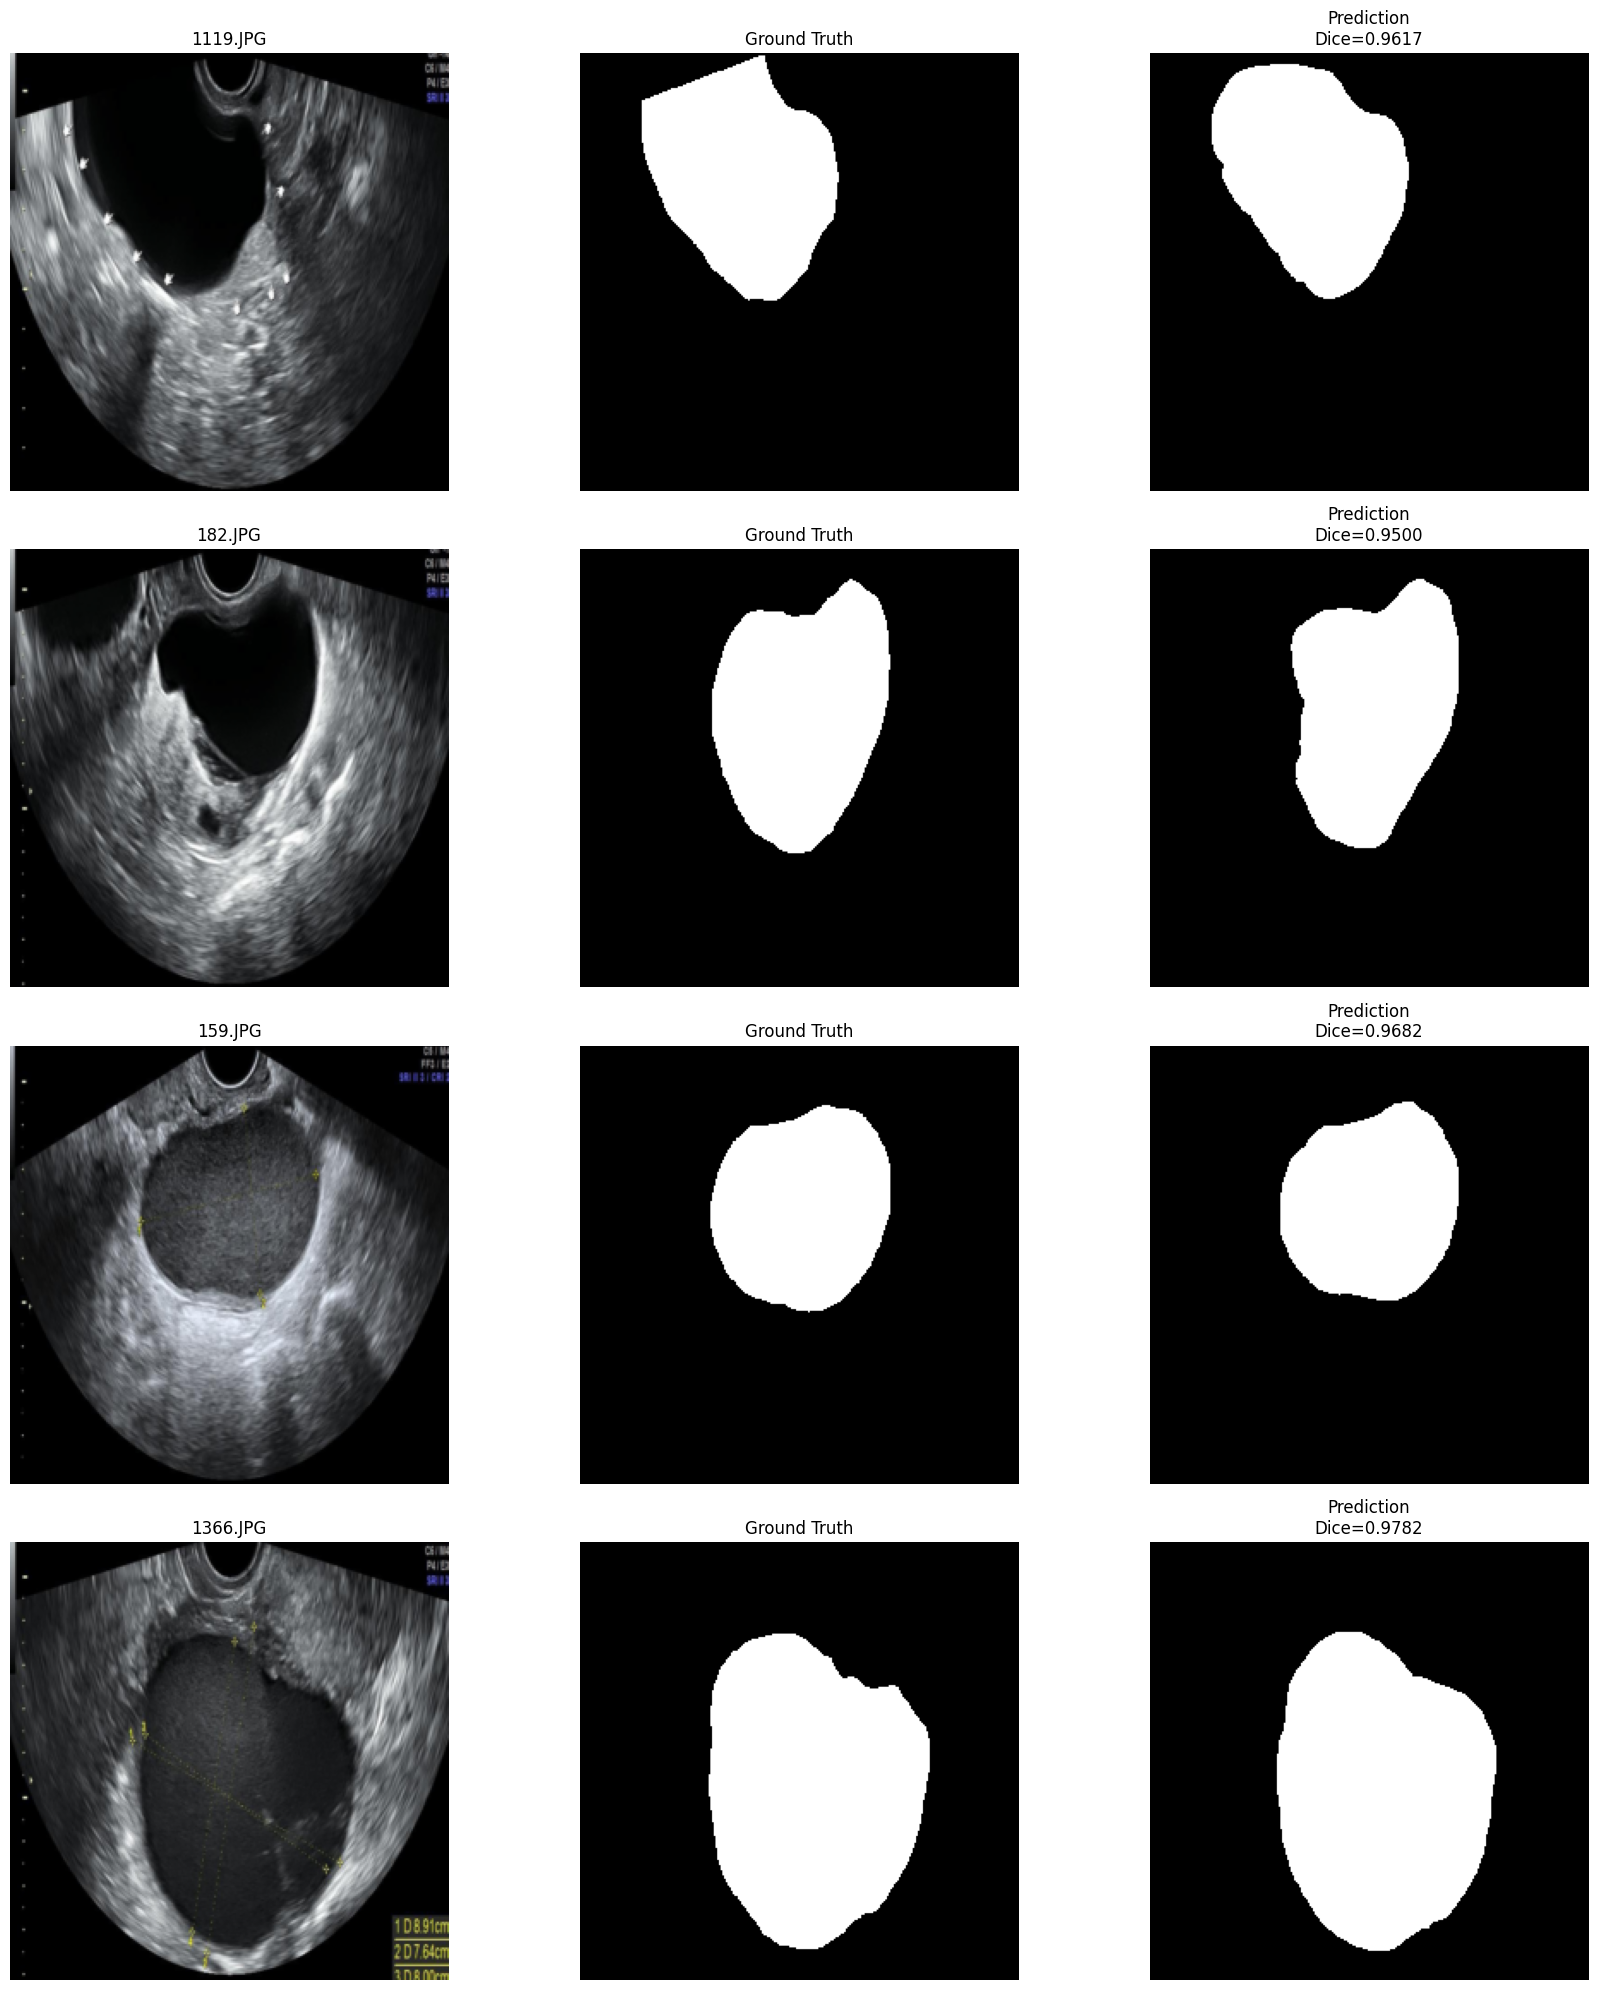


Đã lưu kết quả tại:
/kaggle/working/selected_test_samples.png


In [11]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# ===========================
# 1. Transform
# ===========================
IMAGE_SIZE = 256

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

transform_img = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_mask_binary = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=Image.NEAREST),
    transforms.PILToTensor()
])

def to_long_binary(mask_tensor):
    if mask_tensor.ndim == 3:
        mask_tensor = mask_tensor.squeeze(0)
    return (mask_tensor > 0).long()

# ===========================
# 2. Dice Score
# ===========================
def dice_score(pred_bin, target_bin):
    pred_bin = pred_bin.astype(np.uint8)
    target_bin = target_bin.astype(np.uint8)

    intersection = np.logical_and(pred_bin, target_bin).sum()
    union = pred_bin.sum() + target_bin.sum()

    if union == 0:
        return 1.0 if intersection == 0 else 0.0

    return (2.0 * intersection) / union

# ===========================
# 3. Config
# ===========================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CHECKPOINT_PATH = "/kaggle/input/models/totrang24082004/segformer/pytorch/default/1/best_model.pth"

DATASET_A_ROOT = "/kaggle/input/datasets/totrang24082004/otu2d-dataset/dataset_split"

TEST_IMG_DIR = os.path.join(DATASET_A_ROOT, "test/images")
TEST_MASK_DIR = os.path.join(DATASET_A_ROOT, "test/masks")

OUTPUT_IMAGE = "/kaggle/working/selected_test_samples.png"

# ===========================
# 4. Chọn ảnh cần hiển thị
# ===========================
target_ids = [1119, 182, 159, 1366]

# ===========================
# 5. Load Model
# ===========================
if not os.path.exists(CHECKPOINT_PATH):
    raise FileNotFoundError(
        f"Không tìm thấy checkpoint: {CHECKPOINT_PATH}"
    )

model = SegFormer.from_variant(
    'b5',
    num_classes=1,
    img_size=IMAGE_SIZE,
    decoder_embedding_dim=256
)

# Load checkpoint
ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)

print("=" * 50)
print("Checkpoint type:", type(ckpt))

if isinstance(ckpt, dict):
    print("Checkpoint keys:")
    print(list(ckpt.keys()))
print("=" * 50)

# ---------------------------
# Tự động tìm state_dict
# ---------------------------
if isinstance(ckpt, dict):

    if "model_state" in ckpt:
        print("Loading: ckpt['model_state']")
        state_dict = ckpt["model_state"]

    elif "state_dict" in ckpt:
        print("Loading: ckpt['state_dict']")
        state_dict = ckpt["state_dict"]

    elif "model" in ckpt:
        print("Loading: ckpt['model']")
        state_dict = ckpt["model"]

    elif "net" in ckpt:
        print("Loading: ckpt['net']")
        state_dict = ckpt["net"]

    else:
        # Có thể ckpt chính là state_dict
        first_key = list(ckpt.keys())[0]

        if isinstance(first_key, str):
            print("Checkpoint itself is state_dict")
            state_dict = ckpt
        else:
            raise RuntimeError(
                "Không xác định được state_dict trong checkpoint."
            )
else:
    state_dict = ckpt

# ---------------------------
# Xử lý DataParallel
# ---------------------------
new_state_dict = {}

for k, v in state_dict.items():

    if k.startswith("module."):
        k = k[7:]

    new_state_dict[k] = v

# ---------------------------
# Load weights
# ---------------------------
missing_keys, unexpected_keys = model.load_state_dict(
    new_state_dict,
    strict=False
)

print("\nModel loaded successfully!")

if len(missing_keys):
    print("\nMissing keys:")
    print(missing_keys)

if len(unexpected_keys):
    print("\nUnexpected keys:")
    print(unexpected_keys)

model.to(DEVICE)
model.eval()

print("\nReady for inference!")
# ===========================
# 6. Đọc các ảnh được chọn
# ===========================
samples = []
image_names = []

for img_id in target_ids:

    img_path = os.path.join(
        TEST_IMG_DIR,
        f"{img_id}.JPG"
    )

    mask_path = os.path.join(
        TEST_MASK_DIR,
        f"{img_id}.PNG"
    )

    if not os.path.exists(img_path):
        print(f"Không tìm thấy ảnh: {img_path}")
        continue

    if not os.path.exists(mask_path):
        print(f"Không tìm thấy mask: {mask_path}")
        continue

    img = Image.open(img_path).convert("RGB")
    mask = Image.open(mask_path).convert("L")

    img_tensor = transform_img(img)

    mask_tensor = transform_mask_binary(mask)
    mask_tensor = to_long_binary(mask_tensor)

    samples.append((img_tensor, mask_tensor))
    image_names.append(f"{img_id}.JPG")

NUM_SAMPLES = len(samples)

if NUM_SAMPLES == 0:
    raise RuntimeError("Không tìm thấy ảnh nào trong target_ids")

# ===========================
# 7. Visualization
# ===========================
plt.figure(figsize=(18, 5 * NUM_SAMPLES))

for i, (img_tensor, mask_tensor) in enumerate(samples):

    with torch.no_grad():

        img_batch = img_tensor.unsqueeze(0).to(DEVICE)

        logits = model(img_batch)

        logits_up = torch.nn.functional.interpolate(
            logits,
            size=(IMAGE_SIZE, IMAGE_SIZE),
            mode='bilinear',
            align_corners=False
        )

        pred_prob = torch.sigmoid(
            logits_up
        ).squeeze().cpu().numpy()

        pred_bin = (pred_prob > 0.5).astype(np.uint8)

    # -----------------------
    # Denormalize image
    # -----------------------
    img_np = img_tensor.permute(1, 2, 0).cpu().numpy()

    img_np = img_np * np.array(std) + np.array(mean)

    img_np = np.clip(img_np, 0, 1)

    # -----------------------
    # GT mask
    # -----------------------
    mask_np = mask_tensor.cpu().numpy().astype(np.uint8)

    # -----------------------
    # Dice
    # -----------------------
    dice = dice_score(pred_bin, mask_np)

    # -----------------------
    # Image
    # -----------------------
    plt.subplot(NUM_SAMPLES, 3, i * 3 + 1)

    plt.imshow(img_np)

    plt.title(image_names[i])

    plt.axis("off")

    # -----------------------
    # Ground Truth
    # -----------------------
    plt.subplot(NUM_SAMPLES, 3, i * 3 + 2)

    plt.imshow(mask_np, cmap="gray")

    plt.title("Ground Truth")

    plt.axis("off")

    # -----------------------
    # Prediction
    # -----------------------
    plt.subplot(NUM_SAMPLES, 3, i * 3 + 3)

    plt.imshow(pred_bin, cmap="gray")

    plt.title(f"Prediction\nDice={dice:.4f}")

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    OUTPUT_IMAGE,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nĐã lưu kết quả tại:")
print(OUTPUT_IMAGE)